In [1]:
#Importing libraries 

import pandas as pd
import numpy as np
import time
import copy


In [2]:
num_job = 100
num_mc = 4

In [3]:
#creating the input data for the student ID

import random

def generateData(seed=0):
    PROC = [ [ 0 for m in range(num_mc) ] for j in range(num_job) ]
    random.seed(seed)
    for j in range(num_job):
        for m in range(num_mc):
            PROC[j][m] = random.randint(1,9)
    return PROC

PROC = generateData(8801)

In [4]:
PROC

[[4, 4, 5, 4],
 [8, 1, 8, 8],
 [5, 9, 2, 7],
 [7, 3, 6, 8],
 [2, 2, 9, 8],
 [4, 6, 2, 9],
 [3, 5, 2, 9],
 [3, 7, 9, 7],
 [7, 1, 3, 1],
 [7, 6, 9, 7],
 [3, 3, 2, 3],
 [2, 7, 7, 1],
 [5, 8, 4, 5],
 [7, 3, 4, 7],
 [8, 9, 3, 4],
 [3, 7, 8, 1],
 [6, 3, 2, 4],
 [9, 5, 6, 4],
 [6, 4, 4, 1],
 [4, 6, 2, 4],
 [9, 6, 9, 7],
 [3, 1, 6, 9],
 [6, 5, 2, 5],
 [4, 4, 7, 6],
 [3, 2, 7, 3],
 [2, 1, 5, 7],
 [3, 3, 2, 4],
 [5, 6, 5, 9],
 [6, 8, 2, 1],
 [6, 8, 6, 5],
 [9, 2, 5, 6],
 [9, 3, 4, 6],
 [1, 6, 2, 8],
 [7, 5, 5, 2],
 [1, 2, 5, 3],
 [3, 9, 9, 4],
 [2, 4, 6, 9],
 [2, 8, 9, 5],
 [9, 6, 2, 6],
 [7, 7, 6, 5],
 [5, 9, 5, 7],
 [4, 7, 2, 5],
 [7, 3, 6, 5],
 [4, 5, 1, 2],
 [2, 1, 7, 8],
 [1, 7, 4, 4],
 [8, 4, 1, 8],
 [6, 8, 4, 2],
 [4, 6, 7, 5],
 [2, 7, 9, 7],
 [6, 1, 3, 3],
 [5, 5, 1, 8],
 [9, 9, 6, 2],
 [3, 8, 7, 5],
 [3, 8, 2, 4],
 [6, 1, 2, 7],
 [5, 3, 6, 1],
 [9, 4, 1, 5],
 [8, 9, 2, 7],
 [7, 7, 5, 2],
 [2, 1, 6, 1],
 [9, 5, 2, 7],
 [9, 1, 3, 9],
 [7, 1, 7, 3],
 [1, 2, 4, 8],
 [9, 5, 4, 2],
 [7, 4, 2,

In [5]:
#generate the sequence on how the job runs, default-1,2,3,4

def generateMachineSequence(num_machines):
    return [[m+1 for m in range(num_machines)] for _ in range(num_job)]


machine_sequence = generateMachineSequence(num_mc)
print(machine_sequence)


[[1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2, 3, 4], [1, 2

In [6]:


num_gene=num_mc*num_job # number of genes in a chromosome

pt=PROC
ms=machine_sequence



In [7]:


# raw_input
population_size=30 # default value is 30
crossover_rate=0.8 # default value is 0.8
mutation_rate=0.2  # default value is 0.2
mutation_selection_rate=0.2
num_mutation_jobs=round(num_gene*mutation_selection_rate)
num_iteration= 1500 # default value is 2000
    
start_time = time.time()

Tbest=999999999999999
best_list,best_obj=[],[]
population_list=[]
makespan_record=[]
for i in range(population_size):
    nxm_random_num=list(np.random.permutation(num_gene)) 
    population_list.append(nxm_random_num)
    for j in range(num_gene):
        population_list[i][j]=population_list[i][j]%num_job 
        
for n in range(num_iteration):
    Tbest_now=99999999999           
   
    '''-------- two point crossover --------'''
    parent_list=copy.deepcopy(population_list)
    offspring_list=copy.deepcopy(population_list)
    S=list(np.random.permutation(population_size)) # generate a random sequence to select the parent chromosome to crossover
    
    for m in range(int(population_size/2)):
        crossover_prob=np.random.rand()
        if crossover_rate>=crossover_prob:
            parent_1= population_list[S[2*m]][:]
            parent_2= population_list[S[2*m+1]][:]
            child_1=parent_1[:]
            child_2=parent_2[:]
            cutpoint=list(np.random.choice(num_gene, 2, replace=False))
            cutpoint.sort()
        
            child_1[cutpoint[0]:cutpoint[1]]=parent_2[cutpoint[0]:cutpoint[1]]
            child_2[cutpoint[0]:cutpoint[1]]=parent_1[cutpoint[0]:cutpoint[1]]
            offspring_list[S[2*m]]=child_1[:]
            offspring_list[S[2*m+1]]=child_2[:]
        

    for m in range(population_size):
        job_count={}
        larger,less=[],[] # 'larger' record jobs appear in the chromosome more than m times, and 'less' records less than m times.
        for i in range(num_job):
            if i in offspring_list[m]:
                count=offspring_list[m].count(i)
                pos=offspring_list[m].index(i)
                job_count[i]=[count,pos] # store the above two values to the job_count dictionary
            else:
                count=0
                job_count[i]=[count,0]
            if count>num_mc:
                larger.append(i)
            elif count<num_mc:
                less.append(i)
                
        for k in range(len(larger)):
            chg_job=larger[k]
            while job_count[chg_job][0]>num_mc:
                for d in range(len(less)):
                    if job_count[less[d]][0]<num_mc:                    
                        offspring_list[m][job_count[chg_job][1]]=less[d]
                        job_count[chg_job][1]=offspring_list[m].index(chg_job)
                        job_count[chg_job][0]=job_count[chg_job][0]-1
                        job_count[less[d]][0]=job_count[less[d]][0]+1                    
                    if job_count[chg_job][0]==num_mc:
                        break     
    
    '''--------mutation--------'''   
    for m in range(len(offspring_list)):
        mutation_prob=np.random.rand()
        if mutation_rate >= mutation_prob:
            m_chg=list(np.random.choice(num_gene, num_mutation_jobs, replace=False)) # chooses the position to mutation
            t_value_last=offspring_list[m][m_chg[0]] # save the value which is on the first mutation position
            for i in range(num_mutation_jobs-1):
                offspring_list[m][m_chg[i]]=offspring_list[m][m_chg[i+1]] # displacement
            
            offspring_list[m][m_chg[num_mutation_jobs-1]]=t_value_last # move the value of the first mutation position to the last mutation position
  
    
    '''--------fitness value-------------'''
    total_chromosome=copy.deepcopy(parent_list)+copy.deepcopy(offspring_list) # parent and offspring chromosomes combination
    chrom_fitness,chrom_fit=[],[]
    total_fitness=0
    for m in range(population_size*2):
        j_keys=[j for j in range(num_job)]
        key_count={key:0 for key in j_keys}
        j_count={key:0 for key in j_keys}
        m_keys=[j+1 for j in range(num_mc)]
        m_count={key:0 for key in m_keys}
        
        for i in total_chromosome[m]:
            gen_t=int(pt[i][key_count[i]])
            gen_m=int(ms[i][key_count[i]])
            j_count[i]=j_count[i]+gen_t
            m_count[gen_m]=m_count[gen_m]+gen_t
            
            if m_count[gen_m]<j_count[i]:
                m_count[gen_m]=j_count[i]
            elif m_count[gen_m]>j_count[i]:
                j_count[i]=m_count[gen_m]
            
            key_count[i]=key_count[i]+1
    
        makespan=max(j_count.values())
        chrom_fitness.append(1/makespan)
        chrom_fit.append(makespan)
        total_fitness=total_fitness+chrom_fitness[m]
        
#roulette wheel approach
    
    '''----------selection----------'''
    pk,qk=[],[]
    
    for i in range(population_size*2):
        pk.append(chrom_fitness[i]/total_fitness)
    for i in range(population_size*2):
        cumulative=0
        for j in range(0,i+1):
            cumulative=cumulative+pk[j]
        qk.append(cumulative)
    
    selection_rand=[np.random.rand() for i in range(population_size)]
    
    for i in range(population_size):
        if selection_rand[i]<=qk[0]:
            population_list[i]=copy.deepcopy(total_chromosome[0])
        else:
            for j in range(0,population_size*2-1):
                if selection_rand[i]>qk[j] and selection_rand[i]<=qk[j+1]:
                    population_list[i]=copy.deepcopy(total_chromosome[j+1])
                    break
    '''----------comparison----------'''
    for i in range(population_size*2):
        if chrom_fit[i]<Tbest_now:
            Tbest_now=chrom_fit[i]
            sequence_now=copy.deepcopy(total_chromosome[i])
    if Tbest_now<=Tbest:
        Tbest=Tbest_now
        sequence_best=copy.deepcopy(sequence_now)
        
    makespan_record.append(Tbest)
'''----------result----------'''
print("optimal sequence",sequence_best)
print("optimal value:%f"%Tbest)
print('the elapsed time:%s'% (time.time() - start_time))


'''----------Decode Optimal Sequence----------'''
optimal_sequence = []
for job_index in sequence_best:
    job = job_index % num_job  # Convert gene index back to job index
    optimal_sequence.append(job)

print("Optimal job sequence:", optimal_sequence)


optimal sequence [62, 3, 56, 4, 22, 95, 13, 5, 15, 56, 62, 37, 30, 40, 39, 9, 71, 53, 51, 21, 88, 59, 29, 91, 42, 59, 94, 19, 43, 53, 37, 77, 30, 35, 10, 29, 37, 42, 44, 4, 3, 18, 9, 11, 62, 18, 34, 40, 74, 40, 90, 13, 83, 13, 6, 38, 29, 64, 30, 11, 77, 95, 4, 16, 22, 64, 41, 5, 74, 49, 16, 96, 37, 32, 76, 25, 56, 97, 83, 85, 43, 74, 62, 39, 41, 26, 27, 68, 26, 35, 18, 26, 39, 97, 23, 78, 57, 46, 38, 61, 22, 83, 10, 3, 55, 68, 94, 77, 89, 9, 69, 27, 41, 9, 18, 17, 49, 81, 33, 81, 82, 71, 33, 40, 67, 12, 64, 82, 32, 78, 77, 71, 5, 84, 23, 57, 24, 4, 93, 51, 72, 84, 70, 78, 38, 59, 84, 42, 10, 26, 19, 53, 44, 25, 63, 88, 1, 63, 15, 88, 6, 24, 70, 79, 27, 33, 79, 6, 27, 80, 44, 78, 94, 82, 91, 64, 36, 44, 35, 81, 50, 5, 52, 87, 32, 1, 10, 74, 36, 2, 17, 89, 25, 24, 66, 20, 20, 54, 22, 75, 28, 29, 55, 67, 48, 69, 59, 98, 36, 55, 46, 52, 57, 93, 75, 17, 48, 30, 67, 1, 66, 94, 39, 38, 2, 73, 66, 65, 97, 50, 80, 60, 25, 98, 61, 87, 14, 46, 16, 79, 80, 8, 41, 13, 19, 73, 3, 91, 68, 57, 51, 88,

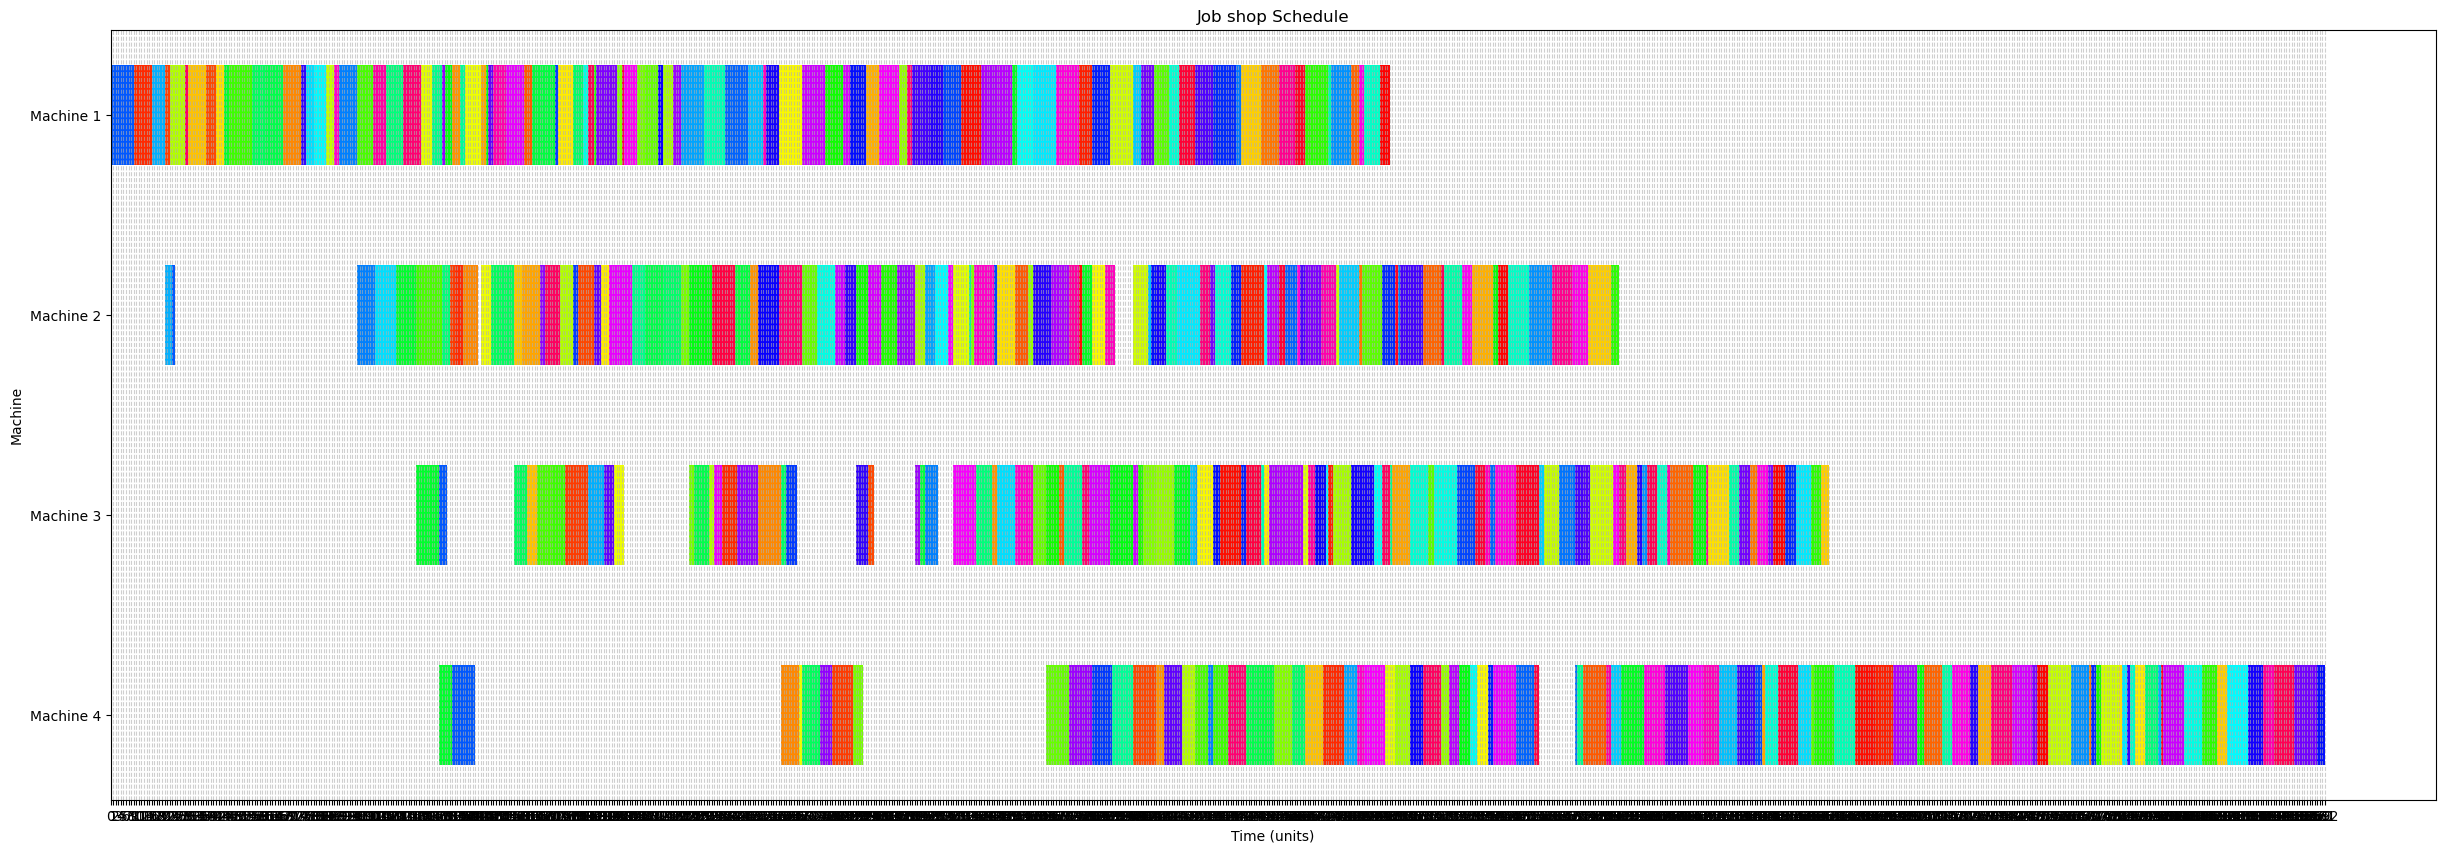


Makespan: 862 units


<Figure size 640x480 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt
import datetime

m_keys = [j + 1 for j in range(num_mc)][::-1]  # Reverse the order of machine keys
j_keys = [j for j in range(num_job)]
key_count = {key: 0 for key in j_keys}
j_count = {key: 0 for key in j_keys}
m_count = {key: 0 for key in m_keys}
j_record = {}

unit = 1  # Define the unit increment

# Assign a color to each job
color_map = plt.get_cmap('hsv')  # Using hsv color map for a continuous spectrum of colors
colors = [color_map(i/num_job) for i in range(num_job)]

for i in sequence_best:
    gen_t = int(pt[i][key_count[i]])
    gen_m = int(ms[i][key_count[i]])
    j_count[i] = j_count[i] + gen_t
    m_count[gen_m] = m_count[gen_m] + gen_t

    if m_count[gen_m] < j_count[i]:
        m_count[gen_m] = j_count[i]
    elif m_count[gen_m] > j_count[i]:
        j_count[i] = m_count[gen_m]

    start_time = j_count[i] - pt[i][key_count[i]] 
    end_time = j_count[i]  
    j_record[(i, gen_m)] = [start_time, end_time]

    key_count[i] = key_count[i] + 1

# Plot Gantt chart using matplotlib
fig, ax = plt.subplots(figsize=(30, 10))  

idle_time = {m: 0 for m in m_keys}
makespan = max(j_count.values())  # Initialize makespan with the maximum job completion time

for m in m_keys:
    prev_end_time = 0  
    for j in j_keys:
        start_time, end_time = j_record[(j, m)]
        duration = end_time - start_time
        ax.barh(y=f'Machine {m}', width=duration, left=start_time * unit, height=0.5, align='center', color=colors[j], label=f'Job {j+1}')

        # Calculate idle time
        if start_time > prev_end_time:
            idle_time[m] += start_time - prev_end_time
        prev_end_time = end_time
ax.set_xlabel('Time (units)')
ax.set_ylabel('Machine')
ax.set_title('Job shop Schedule')
ax.grid(which='both', axis='x', linestyle='--', alpha=0.6)  

ax.set_xticks(range(0, makespan + 1, 1))

plt.show()
plt.tight_layout()

print("\nMakespan:", makespan, "units")


In [9]:
#calculate idle time on each machine

def calculate_idle_time(j_record, num_mc):
    idle_time = {m: 0 for m in range(1, num_mc + 1)}  # Initialize idle time for each machine
    
    # Iterate through the job records
    for m in range(1, num_mc + 1):
        prev_end_time = 0
        for j in j_record:
            start_time, end_time = j_record[j]
            if j[1] == m:  # Check if the job was processed on the current machine
                if start_time > prev_end_time:
                    idle_time[m] += start_time - prev_end_time
                prev_end_time = end_time
    
    # Print idle time for each machine
    print("Idle Time per Machine:")
    for m, time in idle_time.items():
        print(f"Machine {m}: {time} units")
    
    return idle_time


In [10]:
calculate_idle_time(j_record, num_mc)

Idle Time per Machine:
Machine 1: 0 units
Machine 2: 100 units
Machine 3: 215 units
Machine 4: 332 units


{1: 0, 2: 100, 3: 215, 4: 332}